# 200 — TAR · bloque conjunto ξ₁..ξ₄ · E_03 convergencia

Diagnósticos sobre cantidades invariantes a la permutación de etiquetas (log-verosimilitud, error in-sample, átomos activos, entropía, μ, g, π_j). No toca el bloque de prueba.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RAIZ = Path.cwd().resolve().parent
sys.path.insert(0, str(RAIZ))
from mv_psbp.pipeline import *
from mv_psbp import datos, convergencia, evaluacion, comparacion
pd.set_option("display.width", 200)


In [2]:
# [CONFIG]
ESC       = "200"           # escenario de la corrida viva (se lee de fuera, no se modifica)
EID       = "mvb_escenario_200_chungEscG_1_r01_K10"
EID_MV    = "mv_escenario_200_chungEscG_1_r01_K10"       # conjunto completo (K coordenadas), tercer competidor en E_05
DOMINIO   = "simulaciones"
BLOQUE    = (0, 1, 2, 3)         # coordenadas del bloque conjunto (scores activos del generador)
N_CHAINS  = 3
LIMPIAR   = False


,submodelo,variable,rhat,ess_min,geweke_max,media,sd,converge
0,bloque,loglik,1.472,3.959,19.141,-462.557,39.561,False
1,bloque,mse_in,2.367,16.619,3.070,0.657,0.019,False
2,bloque,N_activos,1.635,10.826,7.230,9.255,2.024,False
3,bloque,entropia,4.466,7.535,6.655,1.363,0.193,False
4,bloque,mu,1.561,16.584,5.006,1.877,0.520,False
...,...,...,...,...,...,...,...,...
69,uni_10,entropia,1.050,4.848,3.826,0.644,0.380,False
70,uni_10,mu,1.084,10.542,2.429,0.494,0.617,False
71,uni_10,g,1.002,106.449,2.497,2.340,1.784,False
72,uni_10,pi[coef_10_lag1],1.004,9.076,2.797,0.680,0.286,False


{'gamma_rango_loglik_medio': 5129.800720216113, 'gamma_no_finito': 0, 'min_por_iter': 0.6432850385736182}


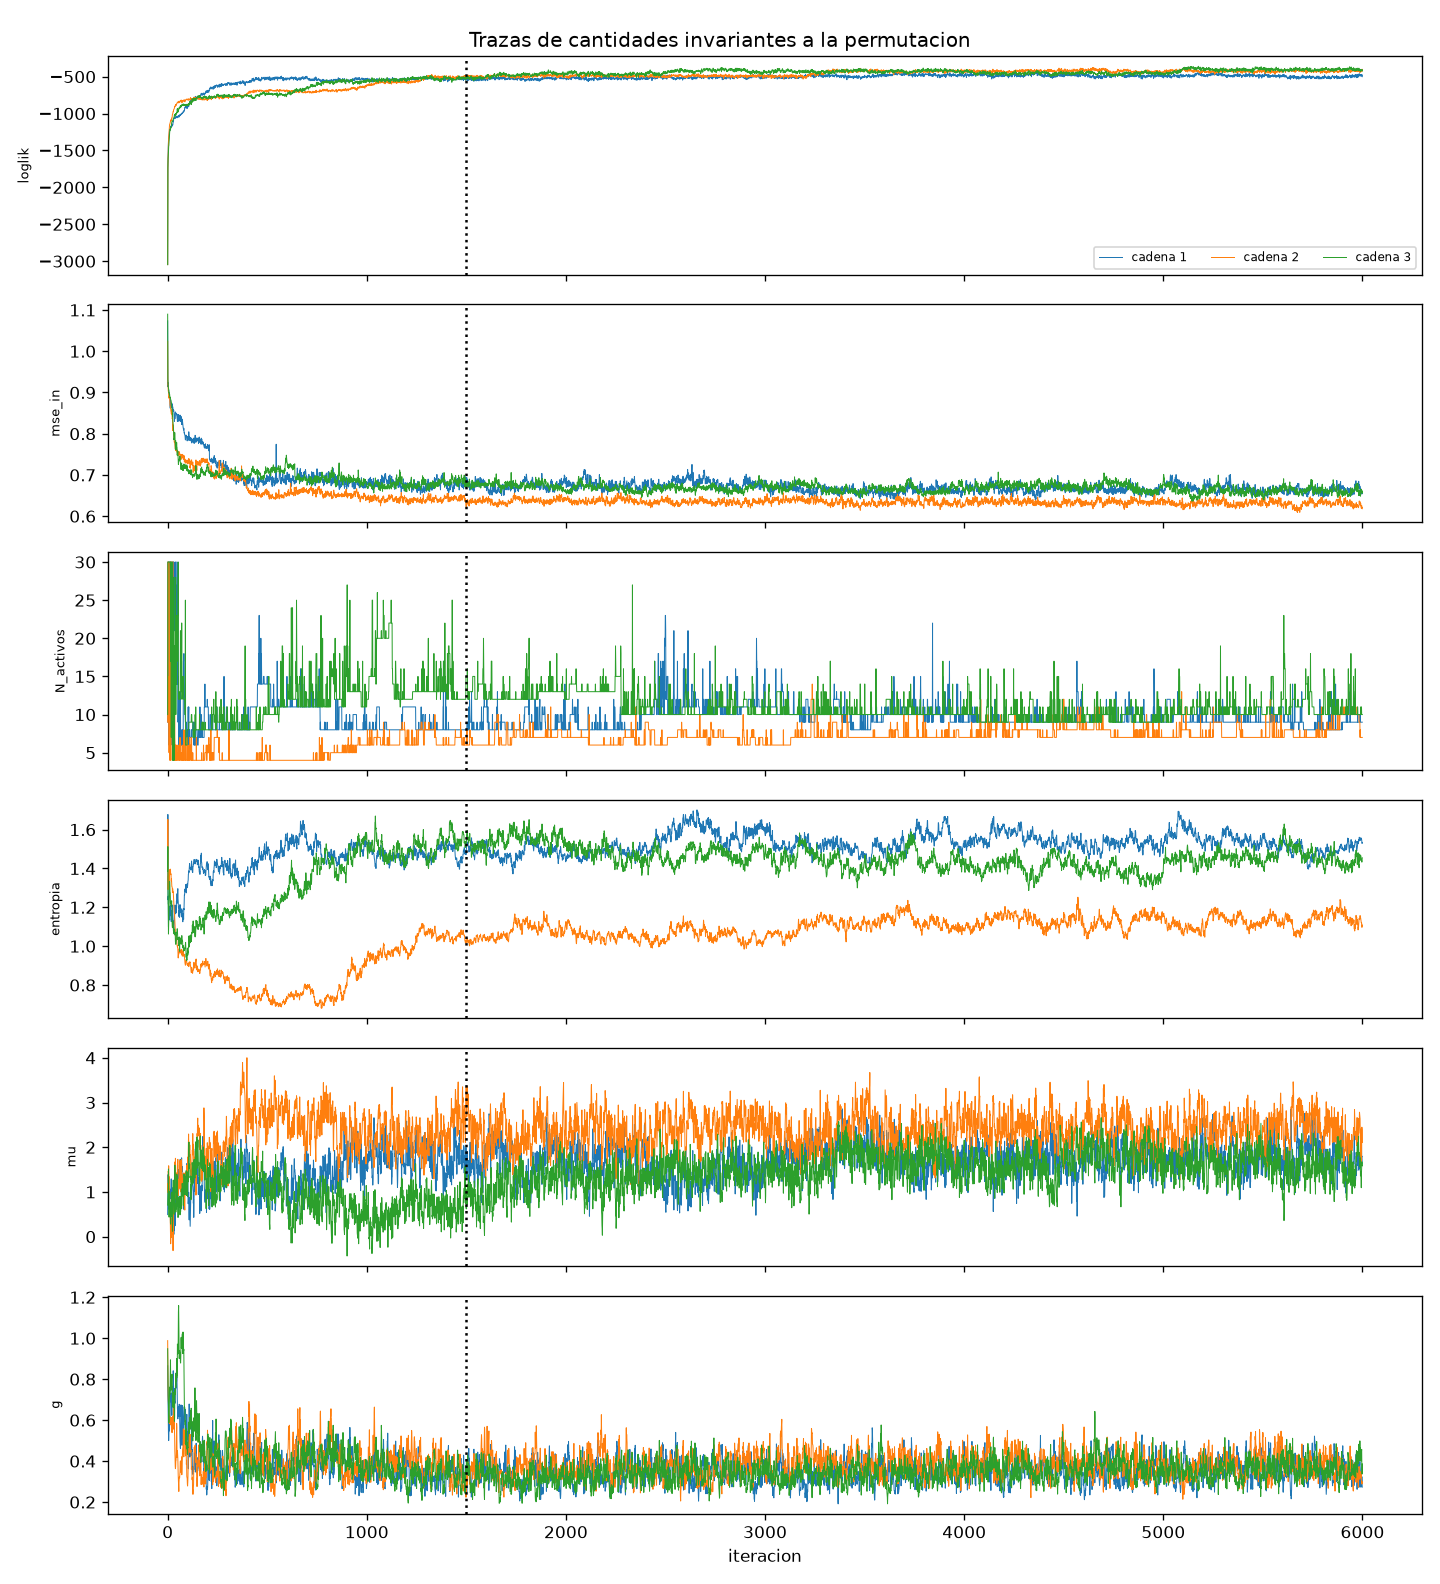

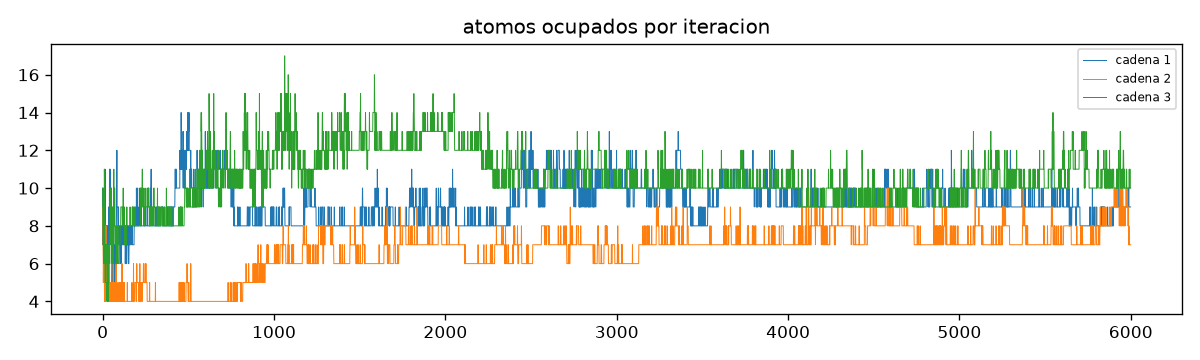

In [3]:
paths = paths_de(EID, DOMINIO)
c = convergencia.paso03(paths, N_CHAINS)
display(c["diagnosticos"].round(3)); print(c["extra"])
display(Image(filename=str(paths["out_report"] / "40_trazas.png")))
display(Image(filename=str(paths["out_report"] / "44_ocupacion.png")))

In [4]:
display(c["pip"].round(3))
pp = c["pip"].set_index("predictor")
ax = pp[["pi_j", "frac_atomos_ocupados_con_j"]].plot.bar(figsize=(12, 3.5)); ax.set_title("inclusión por predictor"); plt.show()

,submodelo,predictor,pi_j,frac_atomos_ocupados_con_j
0,bloque,coef_1_lag1,0.748,0.775
1,bloque,coef_2_lag1,0.717,0.746
2,bloque,coef_3_lag1,0.604,0.616
3,bloque,coef_4_lag1,0.187,0.160
4,bloque,coef_5_lag1,0.007,0.000
5,bloque,coef_6_lag1,0.010,0.001
6,bloque,coef_7_lag1,0.008,0.001
7,bloque,coef_8_lag1,0.009,0.000
8,bloque,coef_9_lag1,0.009,0.000
9,bloque,coef_10_lag1,0.008,0.000


C:\Users\56jua\AppData\Local\Temp\ipykernel_8748\767643145.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax = pp[["pi_j", "frac_atomos_ocupados_con_j"]].plot.bar(figsize=(12, 3.5)); ax.set_title("inclusión por predictor"); plt.show()
